In [ ]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from datasets import Dataset

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/ABSA_BERT')

['university_balanced-new.csv',
 'teacher_balanced-new.csv',
 'course_balanced-new.csv',
 'course_test.csv',
 'teacher_test.csv',
 'university_test.csv',
 'predictions',
 'results',
 'models',
 'training_history']

In [ ]:
university_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_BERT/university_balanced-new.csv"
)

teacher_balanced = pd.read_csv(
    "/content/drive/MyDrive/ABSA_BERT/teacher_balanced-new.csv"
)

course_test = pd.read_csv(
    "/content/drive/MyDrive/ABSA_BERT/course_test.csv"
)

In [ ]:
train_df = pd.concat(
    [university_balanced, teacher_balanced]
).reset_index(drop=True)

test_df = course_test.reset_index(drop=True)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (8436, 5)
Test: (844, 7)


In [ ]:
def format_input(row):

    return (
        "[DOMAIN] " + row["domain"] +
        " [ASPECT] " + row["aspect"] +
        " [TEXT] " + row["review"]
    )

train_df["input_text"] = train_df.apply(
    format_input,
    axis=1
)

test_df["input_text"] = test_df.apply(
    format_input,
    axis=1
)

In [ ]:
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

train_df["label"] = train_df["sentiment"].map(label_map)

test_df["label"] = test_df["sentiment"].map(label_map)

In [ ]:
# =====================================================
# TRAIN / VALIDATION SPLIT
# =====================================================

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,
    stratify=train_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# FIXED SHARED TEST SET
test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7498, 7)
Validation: (938, 7)
Test: (844, 7)


In [ ]:
# =====================================================
# MODEL NAME
# =====================================================

model_name = "vinai/bertweet-base"

# =====================================================
# TOKENIZER
# =====================================================

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    normalization=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["input_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/938 [00:00<?, ? examples/s]

Map:   0%|          | 0/844 [00:00<?, ? examples/s]

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(
            labels,
            preds
        ),

        "f1_macro": f1_score(
            labels,
            preds,
            average="macro"
        ),

        "f1_weighted": f1_score(
            labels,
            preds,
            average="weighted"
        )
    }

In [ ]:
def run_experiment(

    experiment_name,
    learning_rate=1e-5,
    epochs=5,
    use_class_weights=True
):

    model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=3
  )

    if use_class_weights:

        labels = train_df["label"].values

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.unique(labels),
            y=labels
        )

        class_weights_tensor = torch.tensor(
            class_weights,
            dtype=torch.float
        )

        class WeightedTrainer(Trainer):

            def compute_loss(
                self,
                model,
                inputs,
                return_outputs=False,
                **kwargs
            ):

                labels = inputs.get("labels")

                outputs = model(**inputs)

                logits = outputs.get("logits")

                loss_fct = nn.CrossEntropyLoss(
                    weight=class_weights_tensor.to(model.device)
                )

                loss = loss_fct(logits, labels)

                return (loss, outputs) if return_outputs else loss

        trainer_class = WeightedTrainer

    else:

        trainer_class = Trainer

    training_args = TrainingArguments(

        output_dir=f"./{experiment_name}",

        eval_strategy="epoch",

        save_strategy="no",

        learning_rate=learning_rate,

        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,

        num_train_epochs=epochs,

        weight_decay=0.01,

        logging_steps=100,

        fp16=True,

        report_to="none"
    )

    trainer = trainer_class(

        model=model,

        args=training_args,

        train_dataset=train_dataset,
        eval_dataset=val_dataset,

        compute_metrics=compute_metrics
    )

    trainer.train()

    test_results = trainer.evaluate(
        test_dataset
    )

    print(test_results)

    predictions = trainer.predict(
        test_dataset
    )

    y_pred = np.argmax(
        predictions.predictions,
        axis=1
    )

    y_true = predictions.label_ids


    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report_dict = classification_report(

        y_true,
        y_pred,

        target_names=[
            "negative",
            "neutral",
            "positive"
        ],

        output_dict=True
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    report_df.to_csv(

        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_classification_report.csv"
    )

    print(report_df)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    cm_df = pd.DataFrame(

        cm,

        index=[
            "Actual Negative",
            "Actual Neutral",
            "Actual Positive"
        ],

        columns=[
            "Pred Negative",
            "Pred Neutral",
            "Pred Positive"
        ]
    )

    cm_df.to_csv(

        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_confusion_matrix.csv"
    )

    print(cm_df)

    # =====================================================
    # TRAINING HISTORY
    # =====================================================

    history = trainer.state.log_history

    history_df = pd.DataFrame(history)

    history_df.to_csv(

        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_training_history.csv",

        index=False
    )

    print(history_df.head())



    # =====================================================
    # FINAL PREDICTIONS
    # =====================================================

    label_reverse_map = {

        0: "negative",
        1: "neutral",
        2: "positive"
    }

    final_predictions_df = test_df.copy()

    final_predictions_df["true_label"] = y_true

    final_predictions_df["predicted_label"] = y_pred

    final_predictions_df["true_sentiment"] = (

        final_predictions_df["true_label"]
        .map(label_reverse_map)
    )

    final_predictions_df["predicted_sentiment"] = (

        final_predictions_df["predicted_label"]
        .map(label_reverse_map)
    )

    final_predictions_df.to_csv(

        f"/content/drive/MyDrive/ABSA_BERT/predictions/{experiment_name}_predictions.csv",

        index=False
    )

    print(final_predictions_df.head())

    # ERROR ANALYSIS
    errors_df = final_predictions_df[

        final_predictions_df["true_label"]
        != final_predictions_df["predicted_label"]
    ]

    errors_df.to_csv(
        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_errors.csv",
        index=False
    )

    print("Total Errors:", len(errors_df))

    # NEUTRAL ERROR
    neutral_errors = errors_df[

        errors_df["true_sentiment"]
        == "neutral"
    ]

    neutral_errors.to_csv(
        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_neutral_errors.csv",
        index=False
    )

    print("Neutral Errors:", len(neutral_errors))

    # =====================================================
    # METRICS CSV
    # =====================================================

    metrics_df = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Macro_F1",
            "Weighted_F1"
        ],

        "Score": [

            test_results["eval_accuracy"],
            test_results["eval_f1_macro"],
            test_results["eval_f1_weighted"]
        ]
    })

    metrics_df.to_csv(

        f"/content/drive/MyDrive/ABSA_BERT/results/{experiment_name}_metrics.csv",

        index=False
    )

    print(metrics_df)

    # =====================================================
    # SAVE MODEL
    # =====================================================

    trainer.save_model(

        f"/content/drive/MyDrive/ABSA_BERT/models/{experiment_name}"
    )

    tokenizer.save_pretrained(

        f"/content/drive/MyDrive/ABSA_BERT/models/{experiment_name}"
    )

    # =====================================================
    # CLEANUP
    # =====================================================

    trainer.optimizer = None
    trainer.lr_scheduler = None

    del model
    del trainer

    gc.collect()

    torch.cuda.empty_cache()

    torch.cuda.ipc_collect()

    return test_results

In [ ]:
gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [ ]:
epochs5_metrics = run_experiment(
    "university_teacher_to_course_5epochs"
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.783343,0.613210,0.830490,0.694480,0.843823
2,0.503548,0.483314,0.905117,0.794779,0.910058
3,0.444591,0.481405,0.893390,0.767770,0.901324
4,0.324139,0.537030,0.929638,0.831660,0.927302
5,0.262221,0.529567,0.930704,0.841588,0.930224


{'eval_loss': 1.1305639743804932, 'eval_accuracy': 0.7843601895734598, 'eval_f1_macro': 0.7134063978819297, 'eval_f1_weighted': 0.7802132431587318, 'eval_runtime': 1.7124, 'eval_samples_per_second': 492.879, 'eval_steps_per_second': 30.951, 'epoch': 5.0}
              precision    recall  f1-score    support
negative       0.809211  0.845361  0.826891  291.00000
neutral        0.480315  0.420690  0.448529  145.00000
positive       0.859564  0.870098  0.864799  408.00000
accuracy       0.784360  0.784360  0.784360    0.78436
macro avg      0.716363  0.712050  0.713406  844.00000
weighted avg   0.777048  0.784360  0.780213  844.00000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            246            30             15
Actual Neutral              41            61             43
Actual Positive             17            36            355
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.047982   8.727451       0.000010  0.213220   10

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
lr3e5_metrics = run_experiment(
    "university_teacher_to_course_lr3e5",
    learning_rate=3e-5
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.726354,0.552893,0.881663,0.731528,0.881735
2,0.473729,0.446561,0.885928,0.775906,0.899948
3,0.428112,0.511263,0.916844,0.807102,0.916138
4,0.273490,0.725703,0.928571,0.826554,0.924017
5,0.151954,0.797373,0.927505,0.826527,0.924665


{'eval_loss': 1.8649910688400269, 'eval_accuracy': 0.7784360189573459, 'eval_f1_macro': 0.6957672845871604, 'eval_f1_weighted': 0.7668962250222737, 'eval_runtime': 1.6757, 'eval_samples_per_second': 503.672, 'eval_steps_per_second': 31.629, 'epoch': 5.0}
              precision    recall  f1-score     support
negative       0.797342  0.824742  0.810811  291.000000
neutral        0.510000  0.351724  0.416327  145.000000
positive       0.826185  0.897059  0.860165  408.000000
accuracy       0.778436  0.778436  0.778436    0.778436
macro avg      0.711176  0.691175  0.695767  844.000000
weighted avg   0.761920  0.778436  0.766896  844.000000
                 Pred Negative  Pred Neutral  Pred Positive
Actual Negative            240            23             28
Actual Neutral              45            51             49
Actual Positive             16            26            366
       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  0.964869   4.468364       0.000029  0.2132

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Experiment  Accuracy  Macro_F1  Weighted_F1
0   5 Epochs  0.784360  0.713406     0.780213
1  LR = 3e-5  0.778436  0.695767     0.766896


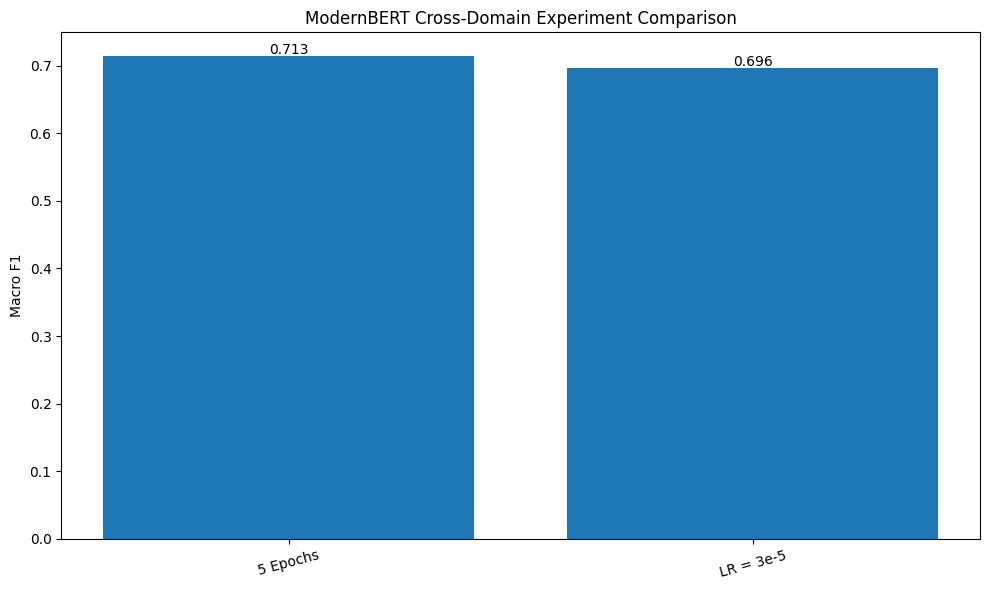

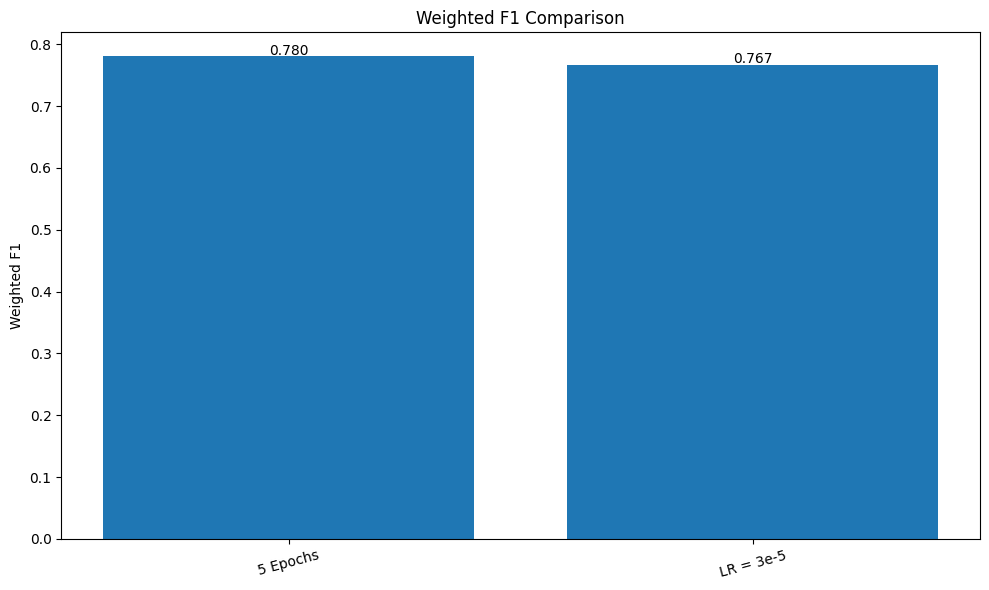

Plots saved successfully


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
# =====================================================
# FINAL RESULTS TABLE
# =====================================================

final_results_df = pd.DataFrame({

    "Experiment": [

        "5 Epochs",
        "LR = 3e-5",
    ],

    "Accuracy": [

        epochs5_metrics["eval_accuracy"],
        lr3e5_metrics["eval_accuracy"],

    ],

    "Macro_F1": [

        epochs5_metrics["eval_f1_macro"],
        lr3e5_metrics["eval_f1_macro"],

    ],

    "Weighted_F1": [

        epochs5_metrics["eval_f1_weighted"],
        lr3e5_metrics["eval_f1_weighted"],

    ]
})

print(final_results_df)

# =====================================================
# SAVE FINAL RESULTS
# =====================================================

final_results_df.to_csv(

    "/content/drive/MyDrive/ABSA_BERT/results/university_teacher_to_course_final_results.csv",

    index=False
)

# =====================================================
# MACRO F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Macro_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Macro F1")

plt.title("ModernBERT Cross-Domain Experiment Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_BERT/results/university_teacher_to_course_macrof1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# WEIGHTED F1 COMPARISON PLOT
# =====================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    final_results_df["Experiment"],
    final_results_df["Weighted_F1"]
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha='center',
        fontsize=10
    )

plt.xticks(rotation=15)

plt.ylabel("Weighted F1")

plt.title("Weighted F1 Comparison")

plt.tight_layout()

plt.savefig(

    "/content/drive/MyDrive/ABSA_BERT/results/university_teacher_to_course_weightedf1.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Plots saved successfully")